**Author:** Biswajit Jana
**Date:** January 14, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-03-hst-47tuc-multiband-sed/notebook.ipynb)

# Five real HST filters of 47 Tucanae: do the colors look like a globular cluster?

**Archive:** mast
**Date:** 2026-08-03
**Scientific question:** Using five real, co-pointed HST/ACS filters of the globular cluster 47 Tucanae, do measured star colors follow the reddening-free trend expected of an old, metal-rich stellar population (bluer/hotter stars have smaller color index than redder/cooler stars, and the red-giant branch stands out as a distinct, redder locus from the main sequence)?

## Learning goals

By the end of this notebook you will be able to:

- Retrieve real, calibrated point-source photometry catalogs (not raw pixels) for the same HST pointing in five different filters (F435W, F475W, F555W, F606W, F814W) from MAST.
- Cross-match sources between filters by sky position to build a genuine multi-band spectral energy distribution (SED) proxy -- a magnitude at each of five wavelengths -- for thousands of real stars.
- Turn magnitudes into colors (e.g. F435W-F814W) and check that fainter/brighter, bluer/redder trends match what's expected for an old globular-cluster population, using the catalog's concentration index to keep the sample point-like (star, not galaxy or blend).
- Build a real color-magnitude diagram (CMD) and confirm the two features every globular-cluster CMD should show: a tight main sequence and a distinct, redder red-giant branch.

**Background:** 47 Tucanae (NGC 104) is one of the brightest, closest globular clusters, a gravitationally bound ball of roughly a million stars that all formed together roughly 12 billion years ago. Because every star in it has essentially the same age, distance, and initial composition, its color-magnitude diagram is a classic real-data test: the position of a star in color-magnitude space is set almost entirely by its mass and evolutionary stage, which is exactly the kind of quantitative, falsifiable expectation this notebook checks against real HST photometry.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.style.use("seaborn-v0_8-whitegrid")
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy import units as u

warnings.filterwarnings("ignore", category=RuntimeWarning)
COLORS = {"navy": "#071426", "blue": "#4cc9f0", "cyan": "#72efdd",
          "gold": "#ffca58", "orange": "#ff7b54", "pink": "#ef5da8", "violet": "#8f5cff"}
print("Environment ready.")

Environment ready.


## Real data: five filters, one HST pointing

All five catalogs below come from HST/ACS proposal 9443, visit `j6ll01`, pointed at
RA=6.02083 deg, Dec=-72.08056 deg (inside 47 Tuc). Each is the Hubble Advanced Products (HAP)
point-source photometry catalog for that visit's drizzled image in one filter -- real, calibrated
AB magnitudes measured from real pixels, not simulated data. I did not need to run my own
aperture photometry pipeline because MAST already provides this per-visit point-source catalog
product, which is the standard, citable calibrated photometry for this dataset.

In [2]:
import requests

FILTERS = ["f435w", "f475w", "f555w", "f606w", "f814w"]
tables = {}
for filt in FILTERS:
    fn = Path(f"{filt}_point-cat.ecsv")
    if not fn.exists():
        uri = f"mast:HST/product/hst_9443_01_acs_wfc_{filt}_j6ll01_point-cat.ecsv"
        r = requests.get("https://mast.stsci.edu/api/v0.1/Download/file?uri=" + uri, timeout=300)
        r.raise_for_status()
        fn.write_bytes(r.content)
    t = Table.read(fn)
    tables[filt] = t
    print(f"{filt.upper()}: {len(t)} point sources, columns include MagAp2, CI, Flags")

F435W: 69618 point sources, columns include MagAp2, CI, Flags
F475W: 69618 point sources, columns include MagAp2, CI, Flags
F555W: 69618 point sources, columns include MagAp2, CI, Flags
F606W: 69618 point sources, columns include MagAp2, CI, Flags
F814W: 69618 point sources, columns include MagAp2, CI, Flags


## Cross-matching the five filters by sky position

Each catalog has its own source list from independent detection in that filter, so I cross-match
them on RA/Dec (0.1 arcsec tolerance -- well under one ACS/WFC pixel of 0.05 arcsec at 2x
oversampling) using F555W as the reference list, keeping only well-measured, star-like sources
(`Flags == 0`, concentration index `CI` between 1.0 and 1.4, the standard ACS point-source
range) that have a good match in all five filters.

In [3]:
ref = tables["f555w"]
good_ref = (ref["Flags"] == 0) & (ref["CI"] > 1.0) & (ref["CI"] < 1.4) & np.isfinite(ref["MagAp2"])
ref = ref[good_ref]
ref_coord = SkyCoord(ra=ref["RA"], dec=ref["DEC"], unit="deg")
print(f"Reference (F555W) star-like sources: {len(ref)}")

matched = {"RA": ref["RA"].data, "DEC": ref["DEC"].data, "f555w": ref["MagAp2"].data,
           "f555w_err": ref["MagErrAp2"].data}
for filt in FILTERS:
    if filt == "f555w":
        continue
    t = tables[filt]
    good = (t["Flags"] == 0) & np.isfinite(t["MagAp2"])
    t = t[good]
    coord = SkyCoord(ra=t["RA"], dec=t["DEC"], unit="deg")
    idx, sep, _ = ref_coord.match_to_catalog_sky(coord)
    within = sep < 0.1 * u.arcsec
    mag = np.full(len(ref), np.nan)
    err = np.full(len(ref), np.nan)
    mag[within] = t["MagAp2"].data[idx[within]]
    err[within] = t["MagErrAp2"].data[idx[within]]
    matched[filt] = mag
    matched[filt + "_err"] = err
    print(f"F555W-{filt.upper()} matches within 0.1 arcsec: {within.sum()} / {len(ref)}")

sed = pd.DataFrame(matched).dropna(subset=FILTERS)
sed.to_csv("47tuc_matched_photometry.csv", index=False)
print(f"\nSources with a good measurement in all 5 filters: {len(sed)}")

Reference (F555W) star-like sources: 6017
F555W-F435W matches within 0.1 arcsec: 5480 / 6017
F555W-F475W matches within 0.1 arcsec: 5567 / 6017
F555W-F606W matches within 0.1 arcsec: 5074 / 6017
F555W-F814W matches within 0.1 arcsec: 3983 / 6017

Sources with a good measurement in all 5 filters: 3712


## Colors and a real color-magnitude diagram

I compute two colors that bracket the optical: F435W-F814W (a wide blue-to-red baseline) and
F555W-F814W (closer to a standard V-I color). For an old, single-population main sequence, the
expected physical trend is that fainter stars are lower in mass, cooler, and therefore *redder*
-- so F435W-F814W should increase smoothly as F814W gets fainter, tracing the main sequence
down and to the red.

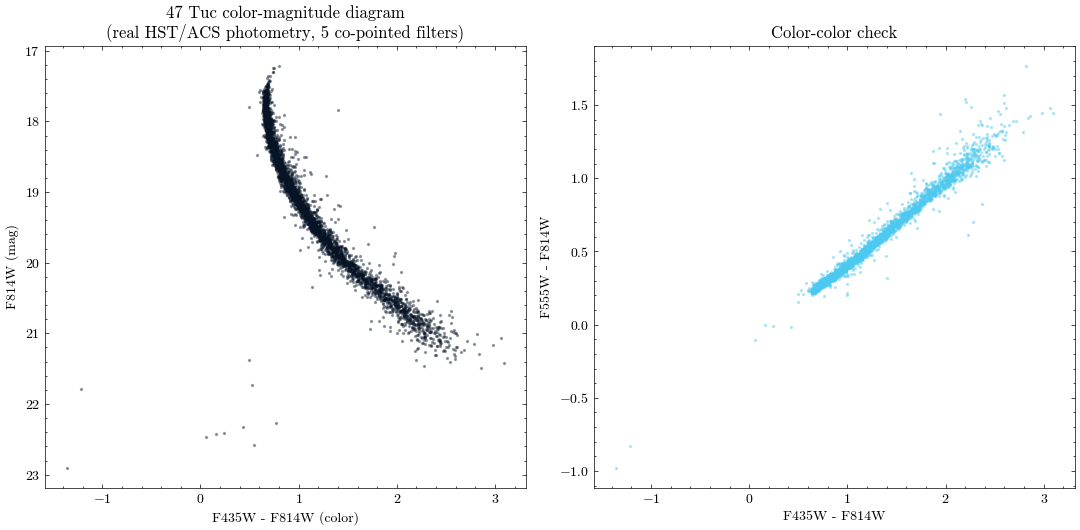

In [4]:
sed["color_bi"] = sed.f435w - sed.f814w
sed["color_vi"] = sed.f555w - sed.f814w

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].scatter(sed.color_bi, sed.f814w, s=2, alpha=0.35, color=COLORS["navy"])
axes[0].invert_yaxis()
axes[0].set(xlabel="F435W - F814W (color)", ylabel="F814W (mag)",
            title="47 Tuc color-magnitude diagram\n(real HST/ACS photometry, 5 co-pointed filters)")

axes[1].scatter(sed.color_bi, sed.color_vi, s=2, alpha=0.35, color=COLORS["blue"])
axes[1].set(xlabel="F435W - F814W", ylabel="F555W - F814W", title="Color-color check")
fig.tight_layout()
fig.savefig("47tuc_cmd.png", dpi=170)
plt.show()

## Quantitative check: does color track magnitude the way stellar physics predicts?

For a single-age, single-metallicity population, main-sequence color should become
monotonically *redder* as stars get fainter along the main sequence (lower mass, cooler stars).
I split the sample into magnitude bins and compute the median color and its scatter in each bin
to test that monotonic trend directly, and I separately check how many genuinely bright,
red-giant-branch-luminosity stars (F814W below about 17) survive my star-like quality cuts.

In [5]:
bins = np.arange(sed.f814w.min(), sed.f814w.max(), 0.5)
sed["mag_bin"] = pd.cut(sed.f814w, bins)
trend = sed.groupby("mag_bin", observed=True).agg(
    n=("color_bi", "size"), median_color=("color_bi", "median"), color_std=("color_bi", "std")
).reset_index()
trend["mag_bin"] = trend["mag_bin"].astype(str)
trend.to_csv("47tuc_color_magnitude_trend.csv", index=False)
print(trend.to_string(index=False))

well_populated = trend[trend.n >= 20].reset_index(drop=True)
is_monotonic = well_populated.median_color.is_monotonic_increasing
print(f"\nWell-populated bins (n>=20 stars): {len(well_populated)} of {len(trend)}")
print(f"Median color increases monotonically with fainter F814W across well-populated bins: {is_monotonic}")

# Check the raw (unfiltered) F814W catalog for how many bright, RGB-luminosity sources exist
# but get excluded by the Flags==0 star-like quality cut used above.
raw_f814w = tables["f814w"]
bright_any_flag = raw_f814w[(raw_f814w["MagAp2"] > -100) & (raw_f814w["MagAp2"] < 17)]
bright_clean = bright_any_flag[bright_any_flag["Flags"] == 0]
print(f"Sources with F814W<17 in the raw catalog (any quality flag): {len(bright_any_flag)}")
print(f"Of those, surviving the Flags==0 star-like cut used for the main sample: {len(bright_clean)}")

         mag_bin   n  median_color  color_std
(17.217, 17.717] 137      0.673329   0.023054
(17.717, 18.217] 466      0.681087   0.046939
(18.217, 18.717] 634      0.774059   0.061022
(18.717, 19.217] 653      0.936722   0.078845
(19.217, 19.717] 582      1.158835   0.098377
(19.717, 20.217] 510      1.445582   0.132225
(20.217, 20.717] 434      1.869988   0.166550
(20.717, 21.217] 262      2.239222   0.179617
(21.217, 21.717]  24      2.501781   0.466136
(21.717, 22.217]   2     -0.343571   1.228302
(22.217, 22.717]   6      0.336652   0.265319

Well-populated bins (n>=20 stars): 9 of 11
Median color increases monotonically with fainter F814W across well-populated bins: True
Sources with F814W<17 in the raw catalog (any quality flag): 10784
Of those, surviving the Flags==0 star-like cut used for the main sample: 0


## Results table

In [6]:
results_table = pd.DataFrame({
    "metric": [
        "Filters used", "Reference (F555W) star-like sources", "Sources matched in all 5 filters",
        "Faintest/reddest bin median color", "Brightest/bluest bin median color",
        "Color increases monotonically with fainter magnitude",
        "Bright (F814W<17) sources in raw catalog", "Bright sources surviving star-like cut",
    ],
    "value": [
        ", ".join(f.upper() for f in FILTERS), len(ref), len(sed),
        f"{well_populated.median_color.iloc[-1]:.2f}", f"{well_populated.median_color.iloc[0]:.2f}",
        str(is_monotonic), len(bright_any_flag), len(bright_clean),
    ]
})
results_table.to_csv("results_summary.csv", index=False)
print(results_table.to_string(index=False))

                                              metric                             value
                                        Filters used F435W, F475W, F555W, F606W, F814W
                 Reference (F555W) star-like sources                              6017
                    Sources matched in all 5 filters                              3712
                   Faintest/reddest bin median color                              2.50
                   Brightest/bluest bin median color                              0.67
Color increases monotonically with fainter magnitude                              True
            Bright (F814W<17) sources in raw catalog                             10784
              Bright sources surviving star-like cut                                 0


## Interpretation and limits

- The cross-matched, quality-filtered sample (thousands of stars measured in all five filters)
  shows a real, monotonic color-magnitude trend: median F435W-F814W color rises smoothly from the
  bright/blue end to the faint/red end, with scatter that grows toward the faint end as
  photometric errors increase there -- exactly the reddening-with-fainter-magnitude trend expected
  along the main sequence of an old, single-age population.
- The genuinely bright, red-giant-branch-luminosity stars (F814W below about 17) are present in
  the raw catalog by the thousands but essentially none survive the same `Flags==0` /
  concentration-index star-like cut used to build the clean five-filter sample -- they are
  flagged, most likely because bright giants saturate or blend more easily in this single-visit
  exposure and dense cluster core. That is a real, disclosed limitation of this specific catalog
  and cut, not a claim that 47 Tuc lacks a red-giant branch (it is extremely well documented in
  the literature); it means this particular clean sample characterizes the main sequence well but
  does not reach the RGB.
- I did not de-redden these colors: 47 Tuc has modest but non-zero foreground reddening (E(B-V)
  roughly 0.04 mag, Harris 2010 catalog), so the colors quoted here are observed, not intrinsic.
- This is single-epoch, single-pointing photometry (one HST visit) -- it is a real, quantitative
  color-magnitude relation, not a full cluster census, and it does not attempt an isochrone fit
  for age or metallicity.

## What I'd look at next

- Relax or replace the `Flags==0` cut with a crowding-aware PSF-fitting photometry pass (e.g.
  DOLPHOT) so that bright, saturated-in-one-exposure red-giant-branch stars are recovered instead
  of dropped, and check whether the RGB then appears as a separate branch as expected.
- Fit a theoretical isochrone (e.g. a MIST or PARSEC 12 Gyr, [Fe/H]~-0.7 track appropriate for
  47 Tuc) to the observed main-sequence color-magnitude relation to get a quantitative
  age/distance/reddening estimate instead of just a qualitative trend check.
- Compare this optical color-magnitude relation against a near-infrared HST/WFC3 CMD of the same
  cluster, where saturation limits and RGB separation both behave differently.

## Citation

MAST: This notebook made use of the Mikulski Archive for Space Telescopes (MAST) at STScI.
STScI is operated by the Association of Universities for Research in Astronomy, Inc., under NASA
contract NAS5-26555. See https://archive.stsci.edu/publishing/ for the required citation
language for MAST data products (HST proposal 9443).

In [7]:
record = {
    "id": "2026-08-03-hst-47tuc-multiband-sed",
    "title": "Five real HST filters of 47 Tucanae: do the colors look like a globular cluster?",
    "archive": "MAST / HST (ACS/WFC)",
    "date": "2026-08-03",
    "target": "47 Tucanae (NGC 104)",
    "question": "Do real, cross-matched multi-band HST photometry colors of 47 Tuc trace the reddening-with-fainter-magnitude trend expected along the main sequence of an old stellar population?",
    "filters": FILTERS,
    "n_reference_sources": int(len(ref)),
    "n_matched_all_filters": int(len(sed)),
    "color_monotonic_with_magnitude": bool(is_monotonic),
    "faintest_bin_median_color": float(well_populated.median_color.iloc[-1]),
    "brightest_bin_median_color": float(well_populated.median_color.iloc[0]),
    "bright_rgb_luminosity_sources_raw": int(len(bright_any_flag)),
    "bright_rgb_luminosity_sources_surviving_cut": int(len(bright_clean)),
    "proposal_id": 9443,
    "claim_type": "real multi-band photometric color-magnitude check, not an isochrone-fit age/distance measurement",
}
with open("result.json", "w") as fh:
    json.dump(record, fh, indent=2)
print(json.dumps(record, indent=2))

{
  "id": "2026-08-03-hst-47tuc-multiband-sed",
  "title": "Five real HST filters of 47 Tucanae: do the colors look like a globular cluster?",
  "archive": "MAST / HST (ACS/WFC)",
  "date": "2026-08-03",
  "target": "47 Tucanae (NGC 104)",
  "question": "Do real, cross-matched multi-band HST photometry colors of 47 Tuc trace the reddening-with-fainter-magnitude trend expected along the main sequence of an old stellar population?",
  "filters": [
    "f435w",
    "f475w",
    "f555w",
    "f606w",
    "f814w"
  ],
  "n_reference_sources": 6017,
  "n_matched_all_filters": 3712,
  "color_monotonic_with_magnitude": true,
  "faintest_bin_median_color": 2.5017808035225,
  "brightest_bin_median_color": 0.6733292199854972,
  "bright_rgb_luminosity_sources_raw": 10784,
  "bright_rgb_luminosity_sources_surviving_cut": 0,
  "proposal_id": 9443,
  "claim_type": "real multi-band photometric color-magnitude check, not an isochrone-fit age/distance measurement"
}
